# <h1><center>Course: Introduction to Machine Learning</center></h1>
# <h1><center>Assignment 1</center></h1>
### <h1><center>Important NOTE: In order to get full credit, for every question, you need to provide the details of your work on how to get to a solution or the end of the proof.</center></h1>
### <h1><center>Instructor: Tan Bui-Thanh</center></h1>
### <h1><center>TA: Cevahir Koprulu</center></h1>
#### <h1><center>Due day: 11:00 pm CDT, Monday, September 14, 2026 </center></h1>
### If you use this jupyter notebook for the assignment, please convert to .pdf file for submission. For other options, all submission MUST be in pdf format, except codes.

---

## Question 1 (See Exercise 1.9 in the notes) - 8 pt

Take the relation $$y = c\,e^{kx}$$ with $c, k$ unknown and positive.

**(1.a) (+4 pt)** Exhibit a transformation of the data after which the relation is linear in the unknowns, and say precisely what the feature map $\boldsymbol\varphi$ is.

**(1.b) (+4 pt)** What has the transformation done to the noise, if the original data was
$$y^i = c\,e^{kx^i} + \varepsilon^i $$

---

## Question 2 (See Exercise 2.3 in the notes) - 8 pt

Let
$$J(\boldsymbol\theta) = \tfrac{1}{2}\boldsymbol\theta^{\mathsf T} \boldsymbol{A}\boldsymbol\theta - \boldsymbol{b}^{\mathsf T}\boldsymbol\theta,
\qquad
\boldsymbol{A} = \begin{bmatrix} 4 & 1 \\ 1 & 3\end{bmatrix},
\qquad
\boldsymbol{b} = \begin{bmatrix} 1 \\ -2 \end{bmatrix}.$$

**(2.a) (+4 pt)** Compute $\nabla_{\boldsymbol\theta} J(\boldsymbol\theta)$ and $\boldsymbol{H}(\boldsymbol\theta)$ by hand.

**(2.b) (+4 pt)** Solve $\nabla_{\boldsymbol\theta} J(\boldsymbol\theta) = \boldsymbol{0}$, and decide using Theorem 2.3.4 of the notes whether the solution is a minimizer.


---

## Question 3 (See Exercise 2.14 in the notes) - 12 pt

Prove that if $J$ is convex and $\nabla_{\boldsymbol\theta} J(\boldsymbol\theta^{\star}) = \boldsymbol{0}$, then $\boldsymbol\theta^{\star}$ is a global minimizer, not merely a local one.


---
## Question 4 (See Exercise 3.9 in the notes) - 12 pt

Theorem 3.3.1 of the notes states:

> $\boldsymbol\Phi^{\mathsf T}\boldsymbol\Phi \succ 0$ if and only if $\boldsymbol\Phi$ has full column rank. In that case $\boldsymbol\Phi^{\mathsf T}\boldsymbol\Phi$ is invertible and the solution of the normal equations is the unique stationary point.

Only a proof sketch is given in Section 3.3. Prove the theorem in full, in both directions.


---

## Question 5 (See Exercise 3.11 in the notes) - 15 pt

Repeat the derivation of Chapter 3 for the weighted loss
$$J(\boldsymbol\theta) = \frac{1}{2n}\sum_{i=1}^{n} w_i\big(f_{\boldsymbol\theta}(\boldsymbol{x}^{i}) - y^{i}\big)^2$$
with fixed $w_i > 0$.

**(5.a) (+10 pt)** Derive $\nabla_{\boldsymbol\theta} J(\boldsymbol\theta)$ and the resulting normal equations. What replaces $\boldsymbol\Phi^{\mathsf T}\boldsymbol\Phi$?

**(5.b) (+5 pt)** Under what condition on the $w_i$ does the invertibility argument of Question 4 still go through?


---

## Question 6 (Linear regression for 2 linear features) - 25 pt

We shall explore the gradient descent algorithm to find an approximate local minimum. See Chapter 4 of the notes for the derivation of the search direction, the role of the step size, and the stopping criteria. Below is a pseudo code.

### **Algorithm: Gradient descent**

**Inputs:** Tolerance $\tau$, initial guess $\boldsymbol{\theta}^i$, $i=0$

*while* $||\nabla_{\boldsymbol{\theta}}J(\boldsymbol{\theta}^i)|| \geq \tau$ do
    
\begin{align*}
    & \boldsymbol{\theta}^{i} := \boldsymbol{\theta}^{i-1} - \alpha \cdot \nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}^{i-1}). \\
    & i = i + 1
\end{align*}

*end*

$\boldsymbol{\theta}^* = \boldsymbol{\theta}^i$


**Output:** The approximate minimizer $\boldsymbol{\theta}^*$

Note that this uses a fixed step size $\alpha$, whereas Algorithm 2 of the notes determines the step by backtracking. Use the fixed step given in the jupyter notebook.

Load the UCI Diabetes Dataset and identify the BMI and BP features, denoted as $x_1, x_2$, respectively. The diabetes risk score is the target variable and is denoted as $y$. We assume the model for linear regression has the following form
$$\bar{y} = 0.4638 + \theta_1 x_1 + \theta_2 x_2 .$$
The mean square error loss function is given by
$$J(\boldsymbol\theta) = \frac{1}{2n}\sum_{i=1}^{n}\big(y^{i} - \bar{y}^{i}\big)^2,$$
where $n$ is the number of patients, $y^{i}$ is the data for the $i$th patient, and $\bar{y}^{i} = 0.4638 + \theta_1 x_1^{i} + \theta_2 x_2^{i}$ with $x_1^{i}$ and $x_2^{i}$ being the BMI and BP features of the $i$th patient.

**(6.a) (+15 pt)** Using the gradient descent algorithm, find the optimal $\theta_1$ and $\theta_2$. You need to use the pseudo code from the jupyter notebook as the skeleton/blueprint for your codes.

**(6.b) (+5 pt)** Plot the contours of the loss function over the square domain $[0,4]^2$.

**(6.c) (+5 pt)** Plot the history the gradient descent vector on the contour map from the two initial guesses $(\theta_1,\theta_2) = (4,4)$ and $(\theta_1,\theta_2) = (0,0)$. You can plot a vector for every 100 iterations.

Optimal Regression Parameters: [3.61061894 0.23010056]


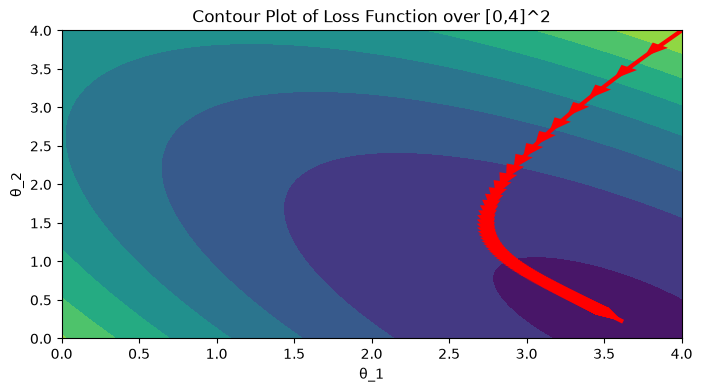

In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 4]

import pandas as pd
from sklearn import datasets

# Note: I am a lazy chud and flipped the axes when defining the functions. To combat this, I just transposed X_train.

def f(x: np.array, theta: np.array):
    # [your work!]
    return 0.4638 + np.dot(x, theta)

def mean_squared_error(theta: np.array, x_data: np.ndarray, y_data: np.ndarray):
    # [your work!]
    sum_se = 0.0
    if x_data.shape[1] != len(y_data):
        return 0.0
    for i in range(len(y_data)):
        sum_se += (y_data[i]-f(x_data[:,i],theta))**2
    return sum_se/(2*len(y_data))

def mse_gradient(theta: np.array, x_data: np.ndarray, y_data: np.ndarray):
    # [your work!]
    grad_mse = np.zeros(x_data.shape[0])
    if x_data.shape[1] != len(y_data):
        return 0
    for i in range(len(y_data)):
        grad_mse += x_data[:,i]*(y_data[i] - f(x_data[:,i],theta))
    return -1*grad_mse/len(y_data)

# Load the diabetes dataset
X, y = datasets.load_diabetes(return_X_y=True, as_frame=True)
# Collect 20 data points and use bmi and bp dimension
X_train = X.iloc[-20:].loc[:, ['bmi', 'bp']].to_numpy()
y_train = (y.iloc[-20:] / 300).to_numpy()

tolerance = 1e-6
step_size = 4e-1
theta =  np.array([4,4])
theta_prev = np.array([1,1])

theta_history = []
theta_history.append(theta)
# [your work!]

while np.linalg.norm(theta - theta_prev) > tolerance:
    # [your work!]
    theta_prev = theta
    theta = theta_prev - step_size*mse_gradient(theta_prev, X_train.T, y_train)
    theta_history.append(theta)

theta_history = np.array(theta_history)
# print(theta_history.shape)
print("Optimal Regression Parameters: " + str(theta))

# Part b: Contours of the MSE loss function
theta1_ctr = np.linspace(0,4,100)
theta2_ctr = np.linspace(0,4,100)

[THETA_1, THETA_2] = np.meshgrid(theta1_ctr,theta2_ctr)
J = np.zeros_like(THETA_1)
for i in range(J.shape[0]):
    for j in range(J.shape[1]):
        param_choices = np.array([THETA_1[i,j], THETA_2[i,j]])
        J[i,j] = mean_squared_error(param_choices,X_train.T,y_train)

fig, ax1 = plt.subplots(1,1)
ax1.contourf(THETA_1,THETA_2,J)
ax1.set_xlabel("θ_1")
ax1.set_ylabel("θ_2")
ax1.set_title("Contour Plot of Loss Function over [0,4]^2")

ax1.plot(theta_history[::100,0], theta_history[::100,1], linewidth=3, color="red")
for i in range(100,theta_history.shape[0],100):
    arrow = theta_history[i+1,0], theta_history[i+1,1], theta_history[i+1,0]-theta_history[i,0], theta_history[i+1,1]-theta_history[i,1]
    plt.arrow(*arrow, shape='full', lw=0, length_includes_head=True, head_width=0.12, color="red")

plt.savefig("gradient_descent_theta0_" + str(theta_history[0,:]) + ".png")

---

## Question 7 (Linear regression for 2 nonlinear features, Multivariate Polynomial Regression) - 20 pt

For this question, we still consider the pairs of BMI and BP features $(x_1, x_2)$ as in Question 6. However, the linear model now is changed to
$$\bar{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1 x_2 + \theta_4 x_1^2 + \theta_5 x_2^2 .$$
The mean square error loss function is still the same
$$J(\boldsymbol\theta) = \frac{1}{2n}\sum_{i=1}^{n}\big(y^{i} - \bar{y}^{i}\big)^2,$$
where, again, $n$ is the number of patients. $\big(x_1^{i}, x_2^{i}, y^{i}\big)$ are the same as in Question 6.

**(+20 pt)** Using the gradient descent algorithm, find the optimal $\boldsymbol\theta^{\star} = \{\theta_i\}_{i=0}^{5}$. You need to use the pseudo code from the jupyter notebook as the skeleton/blueprint for your codes.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 4]

import pandas as pd
from sklearn import datasets

def f(theta: np.array, x: np.array):
    # [your work!]
    x_reg = np.array([1, x[0], x[1], x[0]*x[1], (x[0])**2, (x[1])**2])
    return np.dot(theta, x_reg)

def mean_squared_error(y_data: np.array, theta: np.array, x_data: np.ndarray):
    # [your work!]
    sum_se = 0.0
    n = len(y_data)
    if (x_data.shape[1] != n):
        return 0.0
    for i in range(n):
        sum_se += (y_data[i] - f(theta, x_data[:,i]))**2
    return sum_se/(2*n)

def mse_gradient(y_data: np.array, theta: np.array, x_data: np.ndarray):
    # [your work!]
    mse_grad = np.zeros(6)
    n = len(y_data)
    if (x_data.shape[1] != n):
        return 0.0
    for i in range(n):
        grad_f = np.array([1, x_data[0,i], x_data[1,i], x_data[0,i]*x_data[1,i], (x_data[0,i])**2, (x_data[1,i])**2])
        mse_grad += (y_data[i] - f(theta,x_data[:,i]))*grad_f
    return -1*mse_grad/n

# Load the diabetes dataset
X, y = datasets.load_diabetes(return_X_y=True, as_frame=True)
# Collect 20 data points and use bmi and bp dimension
X_train = (X.iloc[-20:].loc[:, ['bmi', 'bp']])
y_train = (y.iloc[-20:] / 300)

tolerance = 1e-6
step_size = 4e-1
beta = 0.999
theta, theta_prev = np.array([0,0,0,0,0,0]), np.array([1,1,1,1,1,1])
it = 0
# [your work!]
v, v_prev = theta, theta_prev

while np.linalg.norm(theta - theta_prev) > tolerance:
    if it > 200000:
        print("MAX ITERATIONS EXCEEDED")
        break
    # [your work!]
    v_prev = v
    theta_prev = theta
    v = beta*v_prev - step_size*mse_gradient(y_train.to_numpy(), theta_prev, (X_train.to_numpy()).T)
    theta = theta_prev + v
    if it % 10000 == 0:
        print(theta)
    it += 1

print("Optimal Regression Parameters: ", theta)

[0.16826667 0.00147804 0.00107853 0.00033681 0.0004675  0.0004494 ]
[  0.34867363   3.23094265   0.48941564 -12.64157504  24.09291822
  33.82336298]
[  0.34071772   3.28303555   0.4296761  -19.71625478  28.4618371
  37.14201016]
[  0.3393247    3.29032657   0.41770381 -21.07874371  29.33807082
  37.80543096]
[  0.33905139   3.29177365   0.4153534  -21.34524537  29.50920412
  37.93509614]
[  0.33899796   3.29205672   0.41489393 -21.39734694  29.54266195
  37.96044675]
Optimal Regression Parameters:  [  0.33898987   3.2920996    0.41482434 -21.40523832  29.54772952
  37.96428639]


---

## Bonus Question (See Exercise 4.9 in the notes) - 10 pt 

Apply the gradient descent iteration with fixed step $\alpha$ to
$$J(\boldsymbol\theta) = \tfrac{1}{2}\boldsymbol\theta^{\mathsf T}\boldsymbol{A}\boldsymbol\theta$$
with $\boldsymbol{A} \succ 0$ symmetric. Show that
$$\boldsymbol\theta^{j} = (\boldsymbol{I} - \alpha\boldsymbol{A})^{j}\,\boldsymbol\theta^{0},$$
and deduce convergence if and only if
$$0 < \alpha < \frac{2}{\lambda_{\max}(\boldsymbol{A})}.$$